In [23]:
from IPython.display import SVG, display
import recad
import matplotlib.pyplot as plt

import os
print(os.environ['MPLBACKEND'])

module://matplotlib_inline.backend_inline


In [2]:
# Inverting Amplifier

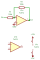

In [29]:
schema = recad.Schema("")
schema.move_to((50.8, 50.8))
schema = (schema
    + recad.LocalLabel("Vin").rotate(180) 
    + recad.Wire().right()
    + recad.Symbol("R1", "100k", "Device:R").rotate(90)
    + recad.Junction()
    + recad.Symbol("U1", "TL072", "Amplifier_Operational:LM2904").anchor("2").mirror("x")
        .property("Sim.Name", "TL072c")
    + recad.Junction()
    + recad.Wire().up().length(5)
    + recad.Symbol("R2", "100k", "Device:R").rotate(270).tox("U1", "2")
    + recad.Wire().toy("U1", "2")
    + recad.Symbol("GND", "GND", "power:GND").at("U1", "3")
    + recad.LocalLabel("Vout").at("U1", "1")

    + recad.Symbol("U1", "TL072", "Amplifier_Operational:LM2904").unit(2)
        .at((70.0, 80.0))
        .property("Sim.Name", "TL072c")
    + recad.Symbol("U1", "TL072", "Amplifier_Operational:LM2904").unit(3)
        .at((90.0, 80.0))
        .property("Sim.Name", "TL072c")
    + recad.Power("+15V").at("U1", "8") 
    + recad.Power("-15V").at("U1", "4").rotate(180)
)

schema.plot(scale=2)

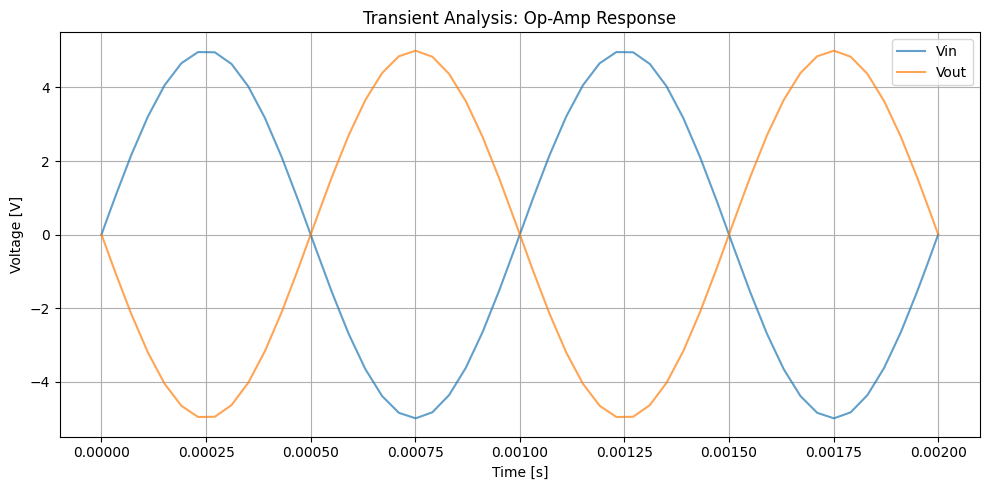

In [34]:
circuit = schema.circuit("summe", ["../spice"])
circuit.voltage("1", "+15V", "GND", "DC 15V")
circuit.voltage("2", "-15V", "GND", "DC -15V")
circuit.voltage("3", "VIN", "GND", "DC 0V SIN(0, 5V, 1k)") # Input Sine wave

simulation = recad.Simulation(circuit)
res = simulation.tran('100u', '2m', '0')

# Plot
t = res["time"]
plt.figure(figsize=(10, 5))
plt.plot(t, res["vin"], label="Vin", alpha=0.7)
plt.plot(t, res["vout"], label="Vout", alpha=0.7)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("Transient Analysis: Op-Amp Response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
